In [337]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [338]:
from Base_Modules.Environments import Prison
from Prison_Strategies.Basic_Strategies import *
from Prison_Strategies.Reinforcement_Learning_Strategies import *
from Base_Modules.Game_Master import Game_Master
from Base_Modules.Action import Action_History, Prison_Actions, Duel_Matrix
import pandas as pd
from collections import defaultdict

In [339]:
prison = Prison()
actions = prison.Get_Actions()

In [340]:
q_learning = Q_Learning(actions=actions, state_size=6, register_enemy_ID=False)

In [341]:
strategies_list = [
    Random_Strategy(actions=actions),
    q_learning,
    Random_Strategy(actions=actions, p_coop=0.1),
    Always_Betray(actions=actions),
    Always_Cooperate(actions=actions),
    Patient_Unforgiving(actions=actions),
    Copycat(actions=actions),
    Periodic(actions=actions, period=1),
    Forgiving(actions=actions),
]

number_of_strategies = len(strategies_list)

In [ ]:
strategies = {}

for (i, s) in enumerate(strategies_list):
    strategies[i] = s
    s.Set_ID(i)

In [ ]:
def Get_Index_By_Name(strategies : dict[int, Strategy], name : str) -> int:
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s) == name:
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if  "".join(str(s).split(":")[1:]).startswith(name):
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s).startswith(name):
            return id
    return -1

def get_name(id : int) -> str:
    return "".join(str(strategies[id]).split(":")[1:])


In [344]:
def Normal_Tournament(gm : Game_Master, number_of_games, total_games_explicit) -> tuple[Duel_Matrix, object]:
    return gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)

def RL_Training(gm : Game_Master, number_of_games, number_of_RL_epochs, total_games_explicit) -> Game_Master:
    for i in range(number_of_RL_epochs):
        gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)
        gm.Reset()
        if (i)%1000 == 0:
            print(i)
    return gm

In [ ]:
number_of_games = 35
number_of_RL_epochs = 100000
total_games_explicit = True
max_action_memory = -1

gm = Game_Master(prison, strategies=strategies, duel_size=2, max_action_memory=max_action_memory)

RL_Training(gm=gm, number_of_games=number_of_games, number_of_RL_epochs=number_of_RL_epochs, total_games_explicit=total_games_explicit)

q_learning.Eval()
duel_matrix, rewards = Normal_Tournament(gm=gm, number_of_games=number_of_games, total_games_explicit=total_games_explicit)
rewards.Sort_Total_Rewards()

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000


## Analiza


In [ ]:
def Sort_Based_On_Total_Rewards(total_rewards, data):
    sorted_data = dict(sorted(
        data.items(),
        key=lambda kv: total_rewards.get(kv[0], 0),
        reverse=True
    ))
    return sorted_data

In [ ]:
total_rewards = rewards.Get_Total_Rewards()
total_rewards_per_name = {str(strategies[i]):total_rewards[i] for i in total_rewards.keys()}

average_rewards_per_match = {k: (float(v)/number_of_strategies) for k, v in total_rewards.items()}
average_rewards_per_round = {k: (float(v)/(number_of_strategies*number_of_games)) for k, v in total_rewards.items()}

duel_rewards = rewards.Get_All_Duel_Rewards()

duel_rewards = dict(sorted(duel_rewards.items(), key=lambda kv: total_rewards.get(kv[0][0]), reverse=True))

In [ ]:
largest_shared_victory = -float("inf")
least_shared_victory = float("inf")

for (_, rewards) in duel_rewards.items():
    largest_shared_victory = max(largest_shared_victory, sum(rewards.values()))
    least_shared_victory = min(least_shared_victory, sum(rewards.values()))


print(f"Largest shared reward: {largest_shared_victory}")
print(f"Least shared reward: {least_shared_victory}")


Largest shared reward: 300
Least shared reward: 103


In [ ]:
from Base_Modules.Nemesis import Nemesis_Best_Enemy_Score, Nemesis_Worst_Score, Nemesis_Largest_Difference

criterion = Nemesis_Worst_Score

nemesis = criterion.Get_Nemesis(duel_rewards=duel_rewards)
nemesis = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=nemesis)
nemesis_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=nemesis)

nemesis_df = pd.DataFrame(
    [(k, v[0]) for k, v in nemesis_per_name.items()],
    columns=["Strategy", "Its nemesis"]
)

In [ ]:
from Base_Modules.Nemesis import Friend_Best_Total_Score, Friend_Best_Own_Score

criterion = Friend_Best_Own_Score

friends = criterion.Get_Nemesis(duel_rewards=duel_rewards)
friends = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=friends)
friends_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=friends)

friends_df = pd.DataFrame(
    [(k, v[0]) for k, v in friends_per_name.items()],
    columns=["Strategy", "Its friend"]
)

In [ ]:
cooperate_stats_per_strategy = {}
for s in strategies.keys():
    stats = duel_matrix.Get_Action_Statistics_Of_Strategy(s)
    cooperate_stats_per_strategy[s] = stats[Prison_Actions.Cooperate]/sum(stats.values())

action_stats_df = pd.DataFrame(
    [(get_name(s):v) for s,v in cooperate_stats_per_strategy.items()],
    columns=["Strategy", "% Coop"]
)
display(action_stats_df)

## Wyniki

In [ ]:
summary = {}
for ix, (id, score) in enumerate(total_rewards.items()):
    summary[ix] = {"Name": get_name(id),
                   "Average score": average_rewards_per_round[id],
                   "Nemesis": get_name(nemesis[id][0]),
                   "Friend": get_name(friends[id][0])}

summary_df = pd.DataFrame.from_dict(summary, orient="index")
summary_df.index.name = "Place"

display(summary_df.round(2))

,Name,Average score,Nemesis,Friend
Place,,,,
0,Patient_Unforgiving (patience=1),2.27,Always_Betray,Random_Strategy (p_coop=0.5)
1,Forgiving (p_forgive=0.1),2.21,Always_Betray,Random_Strategy (p_coop=0.5)
2,Random_Strategy (p_coop=0.1),2.06,Always_Betray,Always_Cooperate
3,Always_Betray,2.06,Patient_Unforgiving (patience=1),Always_Cooperate
4,Copycat (1st=Cooperate),2.00,Always_Betray,Patient_Unforgiving (patience=1)
5,Q_Learning,1.70,Always_Betray,Always_Cooperate
6,Random_Strategy (p_coop=0.5),1.56,Always_Betray,Always_Cooperate
7,Periodic (period=1),1.48,Always_Betray,Always_Cooperate
8,Always_Cooperate,1.38,Always_Betray,Patient_Unforgiving (patience=1)


## Dataframes

In [ ]:
average_reward_per_round_df = pd.DataFrame.from_dict(average_rewards_per_round, orient="index", columns=["Average Reward"])
average_reward_per_round_df.index.name = "Strategy Name"
average_reward_per_round_df = average_reward_per_round_df.round(3)

In [ ]:
# Per match

average_reward_per_match_df = pd.DataFrame.from_dict(average_rewards_per_match, orient="index", columns=["Average Reward"])
average_reward_per_match_df.index.name = "Strategy Name"
average_reward_per_match_df = average_reward_per_match_df.round(3)

In [ ]:
strat_names = [str(strategies[s]) for s in total_rewards.keys()]

score_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

coof = number_of_games

for (s1, s2), scores in duel_rewards.items():
    score_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2]/coof, scores[s1]/coof)
    score_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s1]/coof, scores[s2]/coof)

for s in strat_names:
    score_matrix.loc[s, s] = (0, 0)

In [ ]:
sum_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

for (s1, s2), scores in duel_rewards.items():
    sum_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2] + scores[s1])
    sum_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s2] + scores[s1])

for s in strat_names:
    sum_matrix.loc[s, s] = 0

In [ ]:
victory_matrix = score_matrix.apply(lambda col: col.map(lambda x: int(x[0] > x[1])))
for s in strat_names:
    victory_matrix.loc[s, s] = float("NaN")

In [ ]:
def color_cell(x):
    if not isinstance(x, tuple):
        return ""
    if x[0] == 0 and x[1] == 0:
        return "background-color: black"
    elif x[0] > x[1]:
        return "background-color: green"
    elif x[0] < x[1]:
        return "background-color: darkred"
    else:
        return "background-color: gray"

styled_score_matrix = (
    score_matrix.style
    .map(color_cell)
    .set_properties(**{
        "border": "1px solid black"
    })
    .set_table_styles([
        {"selector": "th", "props": [("border", "2px solid black")]},
        {"selector": "td", "props": [("border", "2px solid black")]}
    ])
)

display(styled_score_matrix)

,(5):Patient_Unforgiving (patience=1),(8):Forgiving (p_forgive=0.1),(2):Random_Strategy (p_coop=0.1),(3):Always_Betray,(6):Copycat (1st=Cooperate),(1):Q_Learning,(0):Random_Strategy (p_coop=0.5),(7):Periodic (period=1),(4):Always_Cooperate
(5):Patient_Unforgiving (patience=1),"(0, 0)","(3.0, 3.0)","(1.78, 0.88)","(0.98, 1.08)","(3.0, 3.0)","(2.58, 0.68)","(3.14, 0.54)","(2.94, 0.64)","(3.0, 3.0)"
(8):Forgiving (p_forgive=0.1),"(3.0, 3.0)","(0, 0)","(1.28, 1.58)","(0.92, 1.32)","(3.0, 3.0)","(2.64, 1.24)","(3.2, 0.9)","(2.86, 0.86)","(3.0, 3.0)"
(2):Random_Strategy (p_coop=0.1),"(0.88, 1.78)","(1.58, 1.28)","(0, 0)","(0.88, 1.48)","(1.24, 1.14)","(3.04, 1.04)","(3.2, 0.7)","(2.9, 0.7)","(4.84, 0.24)"
(3):Always_Betray,"(1.08, 0.98)","(1.32, 0.92)","(1.48, 0.88)","(0, 0)","(1.08, 0.98)","(2.6, 0.6)","(3.0, 0.5)","(3.0, 0.5)","(5.0, 0.0)"
(6):Copycat (1st=Cooperate),"(3.0, 3.0)","(3.0, 3.0)","(1.14, 1.24)","(0.98, 1.08)","(0, 0)","(2.1, 2.2)","(2.3, 2.4)","(2.46, 2.56)","(3.0, 3.0)"
(1):Q_Learning,"(0.68, 2.58)","(1.24, 2.64)","(1.04, 3.04)","(0.6, 2.6)","(2.2, 2.1)","(0, 0)","(2.22, 2.72)","(2.46, 1.76)","(4.84, 0.24)"
(0):Random_Strategy (p_coop=0.5),"(0.54, 3.14)","(0.9, 3.2)","(0.7, 3.2)","(0.5, 3.0)","(2.4, 2.3)","(2.72, 2.22)","(0, 0)","(2.2, 2.3)","(4.04, 1.44)"
(7):Periodic (period=1),"(0.64, 2.94)","(0.86, 2.86)","(0.7, 2.9)","(0.5, 3.0)","(2.56, 2.46)","(1.76, 2.46)","(2.3, 2.2)","(0, 0)","(4.0, 1.5)"
(4):Always_Cooperate,"(3.0, 3.0)","(3.0, 3.0)","(0.24, 4.84)","(0.0, 5.0)","(3.0, 3.0)","(0.24, 4.84)","(1.44, 4.04)","(1.5, 4.0)","(0, 0)"


In [ ]:
import webbrowser
store_styled_matrix_in_html = False
if store_styled_matrix_in_html:
    styled_score_matrix.to_html("styled_score_matrix.html")
    webbrowser.open_new_tab("styled_score_matrix.html")

## Wykresy


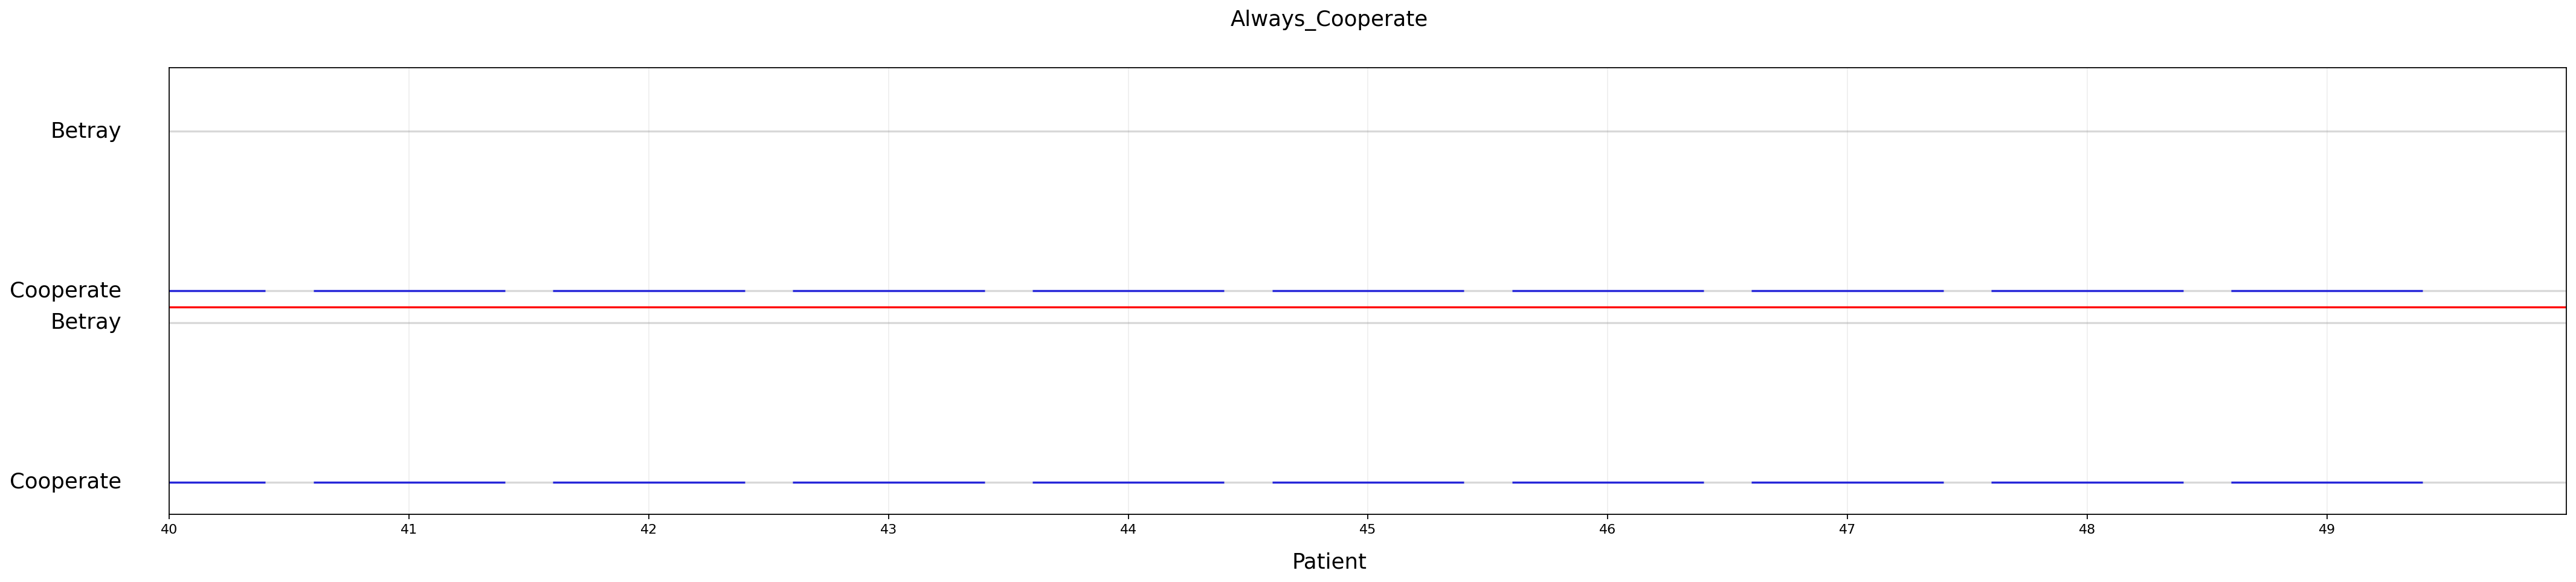

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x_min = number_of_games-10
x_max = number_of_games
strategy1_name = "Always_Cooperate"
strategy2_name = "Patient"

strategy1_ID = Get_Index_By_Name(strategies=strategies, name=strategy1_name)
strategy2_ID = Get_Index_By_Name(strategies=strategies, name=strategy2_name)

assert(strategy1_ID>=0 and strategy2_ID>=0), "Strategy not found."

fontsize=16

data = duel_matrix.Get_Action_History((strategy1_ID, strategy2_ID)).Get_Action_History()

fig = plt.figure(figsize=(32, 6), dpi=160)
y_scale = 0.5
y_offset = 0.6

for i, (key, values) in enumerate(data.items()):
    y, c = [v.value*y_scale - y_offset*i for v in values], ["b" if v.value==0 else "g" for v in values]
    x = list(range(len(y)))

    # plt.step(x, y, where='post', label=f"Signal {key}")
    # plt.scatter(x, y, label=f"Signal {key}")
    for i, val in enumerate(y):
        plt.hlines(val, float(float(i)-0.4), float(float(i)+0.4), colors=[c[i]])

plt.hlines(y = -0.05, xmin=x_min, xmax=x_max, colors=["r"], linestyles="-")
plt.hlines(y = 0, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale-y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = -y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)

plt.xlim([x_min, x_max])
plt.ylim([-y_offset-0.1, y_offset+0.1])
plt.yticks([])
plt.ylabel("")
plt.suptitle(f"{strategy1_name}", fontsize=fontsize, ha="center")


ax = plt.gca()

ax.text(-0.02, 0, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, y_scale, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)

ax.text(-0.02, y_scale-y_offset, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, -y_offset, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)


fig.text(0.5, 0.01, f"{strategy2_name}", ha='center', va='bottom', fontsize=fontsize)

ax.set_xticks(np.arange(x_min, x_max, 1))
ax.grid(True, alpha=0.2)

plt.show()